# Customer Churn Prediction & Retention Analysis System

## Objective
The objective of this project is to build a machine learning model that predicts whether a customer is likely to churn and to identify the key factors responsible for customer churn in a Telecom/SaaS business.

In [1]:
import pandas as pd

In [3]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [7]:
import seaborn as sns

## Dataset Description
The dataset contains customer-level information including tenure, monthly charges, total charges, contract type, payment method, internet services, customer support interactions, add-on services, and churn status.

In [9]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [15]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [17]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Data Cleaning
- Converted TotalCharges column from string to numeric format
- Handled missing values using median imputation

In [19]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [21]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [23]:
df['TotalCharges'].isnull().sum()

0

## Feature Engineering
New features were created to improve model performance:
- Average monthly revenue per customer
- Tenure groups (New, Mid, Loyal)
- Service usage count

In [25]:
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

In [27]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,48,100],
    labels=['New','Mid','Loyal']
)

In [29]:
df['ServiceCount'] = (
    (df[['OnlineSecurity','OnlineBackup','DeviceProtection',
         'TechSupport','StreamingTV','StreamingMovies']] == 'Yes')
    .sum(axis=1)
)

## Exploratory Data Analysis (EDA)
EDA was performed to understand customer behavior and identify patterns related to churn.

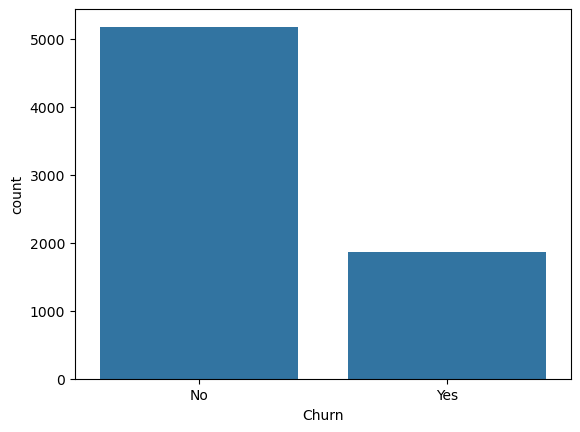

In [31]:
sns.countplot(x='Churn', data=df)
plt.show()

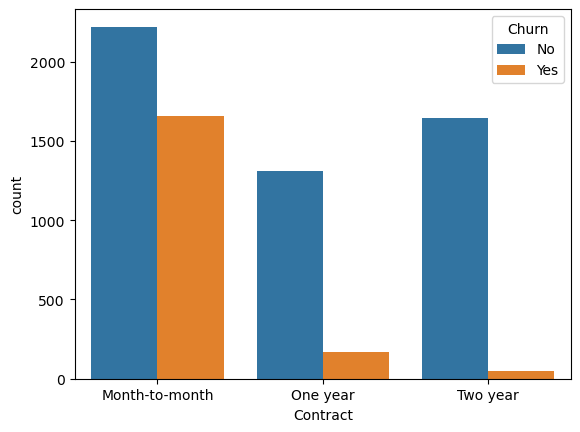

In [33]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

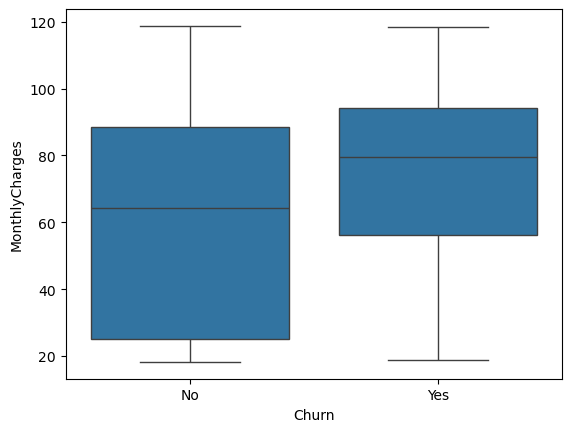

In [35]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

In [37]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [39]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Handling Imbalanced Data
The churn dataset is imbalanced. Class weights were used to give more importance to churned customers during model training.

In [41]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {0: weights[0], 1: weights[1]}

## Feature Scaling
Feature scaling was applied using StandardScaler to improve convergence and performance of Logistic Regression.
## Model Building
Logistic Regression was used as a baseline model, followed by Random Forest for better performance.

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=3000,
    class_weight=class_weights,
    solver='lbfgs'
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight={0: 0.680763653939101, 1: 1.8830213903743316},
                   max_iter=3000)

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [49]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[949  87]
 [190 183]]
              precision    recall  f1-score   support

       False       0.83      0.92      0.87      1036
        True       0.68      0.49      0.57       373

    accuracy                           0.80      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [51]:
importances = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df.head(10)

,Feature,Importance
3,TotalCharges,0.079975
1,tenure,0.078469
4,AvgMonthlySpend,0.070653
2,MonthlyCharges,0.069691
7069,Contract_Two year,0.031554
7054,InternetService_Fiber optic,0.028518
5,ServiceCount,0.028445
7072,PaymentMethod_Electronic check,0.023906
7075,TenureGroup_Loyal,0.022433
7057,OnlineSecurity_Yes,0.020776
